In [7]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import sys
import random
import json
import re
from PIL import ImageEnhance

# ------------------------------------------------------------
# 1. 프로젝트 루트 경로
# ------------------------------------------------------------
BASE_DIR = Path('/content/drive/MyDrive/먼작귀')

# 측면 공통 py가 있는 폴더
PROJECT_DIR = BASE_DIR / 'synthetic_scenarios' / 'side'

# 라벨 exporter가 있는 폴더
LABELER_DIR = BASE_DIR / 'synthetic_scenarios'

if not (PROJECT_DIR / 'side_synthetic_shelf_common.py').exists():
    raise FileNotFoundError(PROJECT_DIR / 'side_synthetic_shelf_common.py')

if not (LABELER_DIR / 'synthetic_label_exporter.py').exists():
    raise FileNotFoundError(LABELER_DIR / 'synthetic_label_exporter.py')

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

if str(LABELER_DIR) not in sys.path:
    sys.path.insert(0, str(LABELER_DIR))

# ------------------------------------------------------------
# 2. import
# ------------------------------------------------------------
import side_synthetic_shelf_common as synth
import synthetic_label_exporter as labeler

ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_사이드.png',
    seed=42,
)

print('공통 py import 완료')
print('라벨 exporter import 완료')
print('공통 py 파일 위치:', PROJECT_DIR / 'side_synthetic_shelf_common.py')
print('라벨 exporter 파일 위치:', LABELER_DIR / 'synthetic_label_exporter.py')
print('BASE_DIR:', BASE_DIR)
print('배경:', ctx['paths']['background_path'])
print('전체 slot 수:', len(ctx['all_slots']))
print('class 수:', len(ctx['class_map']))

# ------------------------------------------------------------
# 3. 다음 저장 번호 찾는 함수
# ------------------------------------------------------------
def get_next_start_index(image_dir, scenario_code):
    image_dir = Path(image_dir)
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3,5}})\.png$')

    max_num = 0

    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)

        if m:
            max_num = max(max_num, int(m.group(1)))

    return max_num + 1

# ------------------------------------------------------------
# 4. S7 측면 합성 기본 설정
# ------------------------------------------------------------
SCENARIO_CODE = 'S7'
SCENARIO_NAME = '조도 변화'
NUM_IMAGES = 140
BASE_SEED = 770770

# SAHI 기준 최종 라벨 저장 경로
IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'side' / SCENARIO_CODE.lower()
PRODUCT_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo' / 'side' / SCENARIO_CODE.lower()
SHELF_LIP_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo_seg' / 'side' / SCENARIO_CODE.lower()
JSON_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_json' / 'side' / SCENARIO_CODE.lower()

for d in [IMAGE_DIR, PRODUCT_YOLO_DIR, SHELF_LIP_YOLO_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None

print('S7 설정 완료')
print('NUM_IMAGES:', NUM_IMAGES)
print('IMAGE_DIR:', IMAGE_DIR)
print('PRODUCT_YOLO_DIR:', PRODUCT_YOLO_DIR)
print('SHELF_LIP_YOLO_DIR:', SHELF_LIP_YOLO_DIR)
print('JSON_DIR:', JSON_DIR)
print('start_idx:', start_idx)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
공통 py import 완료
라벨 exporter import 완료
공통 py 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/side/side_synthetic_shelf_common.py
라벨 exporter 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/synthetic_label_exporter.py
BASE_DIR: /content/drive/MyDrive/먼작귀
배경: /content/drive/MyDrive/먼작귀/창고 이미지/선반이미지_사이드.png
전체 slot 수: 12
class 수: 38
S7 설정 완료
NUM_IMAGES: 140
IMAGE_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/images/side/s7
PRODUCT_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo/side/s7
SHELF_LIP_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo_seg/side/s7
JSON_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_json/side/s7
start_idx: 1


In [8]:
# 조도 변화 함수

def apply_random_lighting(image):
    """
    S7 조도 변화 적용 함수.

    S7은 상품 배치는 정상 진열이고,
    이미지 전체의 밝기/대비만 랜덤하게 바꾼다.

    dark:
        어두운 조명
    normal:
        약한 조도 변화
    bright:
        밝은 조명
    """

    lighting_mode = random.choice(["dark", "normal", "bright"])

    if lighting_mode == "dark":
        brightness_factor = random.uniform(0.68, 0.84)
        contrast_factor = random.uniform(0.90, 1.02)

    elif lighting_mode == "normal":
        brightness_factor = random.uniform(0.92, 1.06)
        contrast_factor = random.uniform(0.95, 1.05)

    elif lighting_mode == "bright":
        brightness_factor = random.uniform(1.08, 1.22)
        contrast_factor = random.uniform(0.96, 1.08)

    # 밝기 적용
    image = ImageEnhance.Brightness(image).enhance(brightness_factor)

    # 대비 적용
    image = ImageEnhance.Contrast(image).enhance(contrast_factor)

    lighting_info = {
        "lighting_mode": lighting_mode,
        "brightness_factor": round(brightness_factor, 4),
        "contrast_factor": round(contrast_factor, 4),
    }

    return image, lighting_info

[PNG 선택: S_ROW_KEYWORD] A10006 | row_1 | 30_s_23 | A10006_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 50135 | row_1 | 30_s_24 | 50135_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 50079 | row_1 | 30_s_24 | 50079_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 25165 | row_2 | 30_s_24 | 25165_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 75061 | row_2 | 30_s_24 | 75061_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35882 | row_2 | 30_s_24 | 35882_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 15019 | row_3 | 30_s_24 | 15019_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 66245 | row_3 | 30_s_24 | 66245_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 40310 | row_3 | 30_s_24 | 40310_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 55337 | row_4 | 30_s_23 | 55337_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 70205 | row_4 | 30_s_24 | 70205_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 45026 | row_4 | 30_s_24 | 45026_30_s_24_sam_object

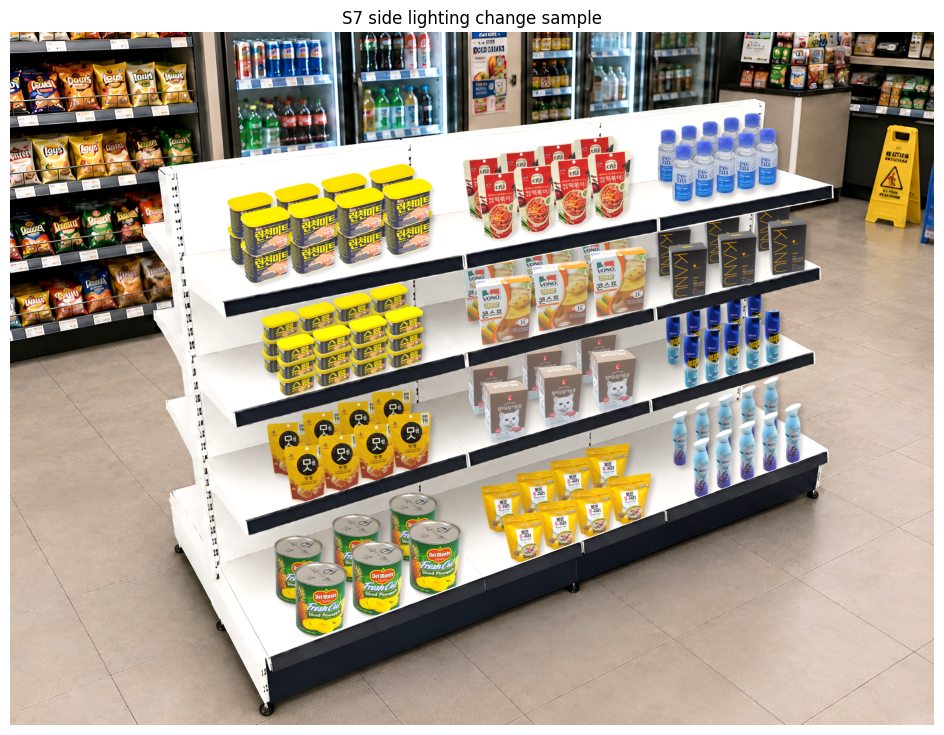

In [9]:
# ============================================================
# S7 측면 합성 + 이미지/라벨 저장
# 조도 변화: 정상 진열 + 전역 밝기/대비 변화
# ============================================================

for image_idx in range(NUM_IMAGES):
    seed = BASE_SEED + image_idx

    random.seed(seed)
    synth.reset_random_seed(seed)

    # ------------------------------------------------------------
    # 1. 이미지마다 ctx 새로 생성
    # ------------------------------------------------------------
    ctx = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_사이드.png',
        seed=seed,
    )

    # ------------------------------------------------------------
    # 2. S7은 상품 배치는 정상 진열 기준
    # ------------------------------------------------------------
    slot_plan = synth.make_normal_slot_plan(ctx)

    for slot_id, target in slot_plan.items():
        front_qty = int(target['normal_front_qty'])
        back_qty = int(target['normal_back_qty'])

        target.update({
            'scenario_code': SCENARIO_CODE,
            'scenario_name': SCENARIO_NAME,
            'sub_scenario_code': SCENARIO_CODE,
            'action': 'lighting_change',
            'list_up': False,
            'final_status': '정상',

            'display_qty': front_qty,
            'back_display_qty': back_qty,

            'front_missing_indices': [],
            'back_missing_indices': [],
            'back_visible_indices': None,
            'extra_misplaced_items': [],

            'missing_qty': 0,
            'reduced_front_qty': front_qty,
            'target_column_index': None,
            'is_misplaced': False,
        })

    # ------------------------------------------------------------
    # 3. 렌더링
    # ------------------------------------------------------------
    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx,
        slot_plan=slot_plan,
        seed=seed
    )

    # ------------------------------------------------------------
    # 4. 조도 변화 적용
    # ------------------------------------------------------------
    result, lighting_info = apply_random_lighting(result)

    # ------------------------------------------------------------
    # 5. 저장 파일명
    # ------------------------------------------------------------
    file_no = start_idx + image_idx

    save_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.png'
    yolo_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.txt'
    json_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.json'

    save_path = IMAGE_DIR / save_name
    product_yolo_path = PRODUCT_YOLO_DIR / yolo_name
    shelf_lip_yolo_path = SHELF_LIP_YOLO_DIR / yolo_name
    json_path = JSON_DIR / json_name

    # ------------------------------------------------------------
    # 6. 이미지 + SAHI 기준 라벨 3종 저장
    # save_sahi_labels()에는 lighting_info 인자가 없으므로
    # 저장 후 JSON을 다시 열어서 lighting_info를 추가한다.
    # ------------------------------------------------------------
    label_result = labeler.save_sahi_labels(
        result=result,
        objects=objects,
        slot_labels=slot_labels,
        ctx=ctx,
        scenario_code=SCENARIO_CODE,
        scenario_name=SCENARIO_NAME,
        image_path=save_path,
        product_yolo_path=product_yolo_path,
        shelf_lip_yolo_path=shelf_lip_yolo_path,
        slot_json_path=json_path,
        seed=seed,
        view='side',
        settings_extra={
            'scenario_rule': 'normal placement with random global lighting change',
            'lighting_modes': ['dark', 'normal', 'bright'],
            's7_method': 'global_brightness_contrast_augmentation',
        }
    )

    # ------------------------------------------------------------
    # 7. 저장된 JSON에 S7 조도 정보 추가
    # ------------------------------------------------------------
    with open(json_path, 'r', encoding='utf-8') as f:
        label_json = json.load(f)

    label_json['lighting_info'] = lighting_info

    if 'settings' not in label_json:
        label_json['settings'] = {}

    label_json['settings']['scenario_rule'] = 'normal placement with random global lighting change'
    label_json['settings']['lighting_modes'] = ['dark', 'normal', 'bright']
    label_json['settings']['s7_method'] = 'global_brightness_contrast_augmentation'

    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(label_json, f, ensure_ascii=False, indent=2)

    saved_paths.append(save_path)
    last_result = result

    generation_logs.append({
        'file_name': save_name,
        'seed': seed,
        'scenario_code': SCENARIO_CODE,
        'scenario_name': SCENARIO_NAME,
        'lighting_info': lighting_info,
        'lighting_mode': lighting_info.get('lighting_mode'),
        'brightness_factor': lighting_info.get('brightness_factor'),
        'contrast_factor': lighting_info.get('contrast_factor'),
        'n_objects': len(objects),
        'n_slots': len(slot_labels),
        'image_path': str(save_path),
        'product_yolo_path': str(product_yolo_path),
        'shelf_lip_yolo_path': str(shelf_lip_yolo_path),
        'json_path': str(json_path),
        'label_result': label_result,
    })

    if (image_idx + 1) % 20 == 0:
        print(f'[{image_idx + 1}/{NUM_IMAGES}] 생성 완료:', save_name, '| lighting:', lighting_info)

print('S7 생성 완료')
print(f'총 생성 수: {len(saved_paths)}장')
print('이미지 저장 폴더:', IMAGE_DIR)
print('상품 YOLO 저장 폴더:', PRODUCT_YOLO_DIR)
print('선반 앞턱 YOLO-seg 저장 폴더:', SHELF_LIP_YOLO_DIR)
print('slot_state JSON 저장 폴더:', JSON_DIR)

print('처음 5개 파일:')
for p in saved_paths[:5]:
    print('-', p.name)

print('마지막 이미지:', saved_paths[-1])
synth.show_image(last_result, title=f'{SCENARIO_CODE} side lighting change sample')

In [10]:
# ============================================================
# S7 생성 로그 확인
# ============================================================

last_log = generation_logs[-1]

print('파일명:', last_log['file_name'])
print('시나리오:', last_log['scenario_code'], last_log['scenario_name'])
print('조도 모드:', last_log['lighting_mode'])
print('밝기 계수:', last_log['brightness_factor'])
print('대비 계수:', last_log['contrast_factor'])
print('객체 수:', last_log['n_objects'])
print('slot 수:', last_log['n_slots'])
print('이미지:', last_log['image_path'])
print('상품 YOLO:', last_log['product_yolo_path'])
print('선반 앞턱 YOLO-seg:', last_log['shelf_lip_yolo_path'])
print('slot_state JSON:', last_log['json_path'])

파일명: synthetic_s7_140.png
시나리오: S7 조도 변화
조도 모드: bright
밝기 계수: 1.2144
대비 계수: 1.0286
객체 수: 118
slot 수: 12
이미지: /content/drive/MyDrive/먼작귀/dataset/synthetic/images/side/s7/synthetic_s7_140.png
상품 YOLO: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo/side/s7/synthetic_s7_140.txt
선반 앞턱 YOLO-seg: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo_seg/side/s7/synthetic_s7_140.txt
slot_state JSON: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_json/side/s7/synthetic_s7_140.json


In [11]:
# ============================================================
# S7 JSON 확인
# ============================================================

sample_json_path = Path(generation_logs[-1]['json_path'])

with open(sample_json_path, 'r', encoding='utf-8') as f:
    sample_json = json.load(f)

print('JSON top-level keys:')
print(sample_json.keys())
print()

print('overview:')
print(sample_json.get('overview', {}))
print()

print('lighting_info:')
print(sample_json.get('lighting_info', {}))
print()

print('settings:')
print(sample_json.get('settings', {}))
print()

print('objects 개수:', len(sample_json.get('objects', [])))
print('slots 개수:', len(sample_json.get('slots', [])))
print('work_list 개수:', len(sample_json.get('work_list', [])))

JSON top-level keys:
dict_keys(['image', 'overview', 'planogram', 'front_lines', 'slots', 'objects', 'shelf_lips', 'work_list', 'sku_detail_candidates', 'class_map', 'settings', 'lighting_info'])

overview:
{'total_slot_count': 12, 'normal_slot_count': 12, 'replenish_required_count': 0, 'order_required_count': 0, 'check_required_count': 0, 'list_up_count': 0, 'misplaced_slot_count': 0, 'empty_slot_count': 0, 'front_depleted_slot_count': 0}

lighting_info:
{'lighting_mode': 'bright', 'brightness_factor': 1.2144, 'contrast_factor': 1.0286}

settings:
{'generator_version': 'side_synthetic_v1', 'modeling_strategy': 'sahi_slicing_inference', 'coordinate_system': 'full_image', 'product_yolo_include_rule': 'visible front and back products are included', 'shelf_lip_class': {'0': 'shelf_lip'}, 'sahi_config': {'enabled': True, 'slice_height': 640, 'slice_width': 640, 'overlap_height_ratio': 0.2, 'overlap_width_ratio': 0.2, 'postprocess_type': 'NMS'}, 'status_rule': {'NORMAL': 'no issue', 'REPLEN